## Support Vector Machine (SVM) tutorial

by Kris Lokere

In this notebook, we will look at Support Vector Machines

The goal of this notebook is to get a better understanding of SVMs and to write some code for training SVMs , including nonlinear SVMs using kernel techniques. We provide a code skeleton and mark the bits and pieces that you need to implement yourself.

In [38]:
# we'll do most of this using basic linear algebra functions
import numpy as np

### Kernel Support Vector Machine (SVM)

A Kernel SVM is a powerful classification algorithm that extends the capabilities of linear SVMs to handle non-linearly separable data. It achieves this by implicitly mapping the input features into a higher-dimensional feature space where a linear separator can be found.

The 'kernel trick' allows us to compute the dot product of the transformed feature vectors in this higher-dimensional space without explicitly performing the transformation. This is done using a kernel function, k(xᵢ, xⱼ), which calculates the similarity between two data points.

Here, we'll demonstrate a **Gaussian (Radial Basis Function - RBF) kernel**.

### Generate and Visualize the Data

In [39]:
# Generate a non-linearly separable dataset
# Scikit Learn has some nice built-in functions for this
from sklearn.datasets import make_circles
# this will make concentric circles with some noise
X, y = make_circles(n_samples=100, factor=0.5, noise=0.2, random_state=42)

In [40]:
# how is the X data organized? Rows? columns? How many samples and features?
print(X.shape) # <-- EDIT THIS

(100, 2)


In [41]:
# in case we need it later, call the number of samples N and number of features D
N = X.shape[0] # <-- EDIT THIS
D = X.shape[1] # <-- EDIT THIS
print(f"Number of samples: {N}")
print(f"Number of features: {D}")

Number of samples: 100
Number of features: 2


In [42]:
# what are the values for the labels?
# Python has a function "set()" that does the same as the mathematical notion of a set!
set(y)

{np.int64(0), np.int64(1)}

In [43]:
# Adjust labels to be -1 and 1 for SVM
y[y == 0] = -1

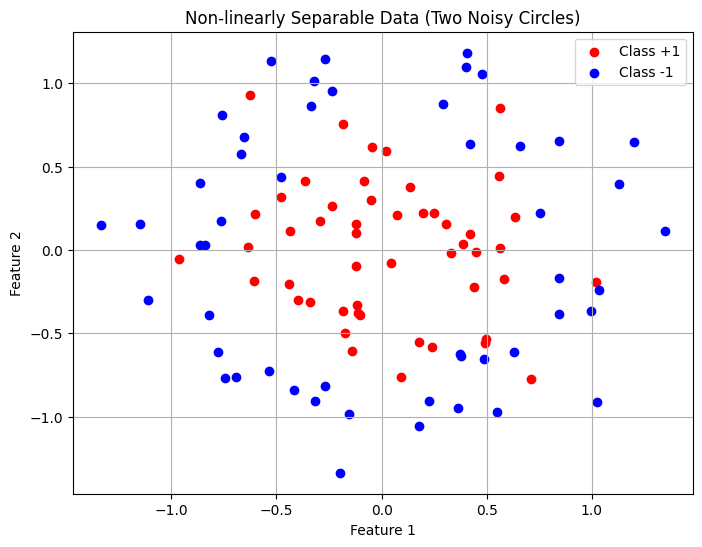

In [44]:
# Visualize the dataset
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
# select the X values that have a label y == 1 and plot them as 'red'
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='red', label='Class +1')
# select the X values that have a label y == -1 and plot them as 'blue'
plt.scatter(X[y == -1, 0], X[y == -1, 1], color='blue', label='Class -1') # <-- EDIT THIS
plt.title('Non-linearly Separable Data (Two Noisy Circles)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

### Implement the RBF Kernel Function in NumPy

The Radial Basis Function (RBF) or Gaussian kernel is a common choice for non-linear SVMs. It is defined as:

$$k(x_i, x_j) = exp(-\gamma ||x_i - x_j||^2)$$

where $\gamma$ (gamma) is a hyperparameter that defines how quickly the function goes to zero.

In [45]:
# define kernel function between two vectors
def rbf(x1, x2, gamma=1.0):
    """
    Computes the RBF (Gaussian) kernel matrix between two vectors x1 and x2

    Inputs:
        x1 (np.ndarray): First vector (n_features).
        X2 (np.ndarray): Second vector (n_features).
        gamma (float): Kernel coefficient.

    Returns:
        np.ndarray: Kernel result (scalar).
    """
    # Calculate the squared Euclidean distance between the two vectors
    sq_distance =  np.sum((x1 - x2) ** 2) # <-- EDIT THIS

    # Apply the RBF kernel formula
    return np.exp(-gamma * sq_distance)

In [46]:
# extend this to an entire dataset at once
def rbf_kernel(X1, X2, gamma=1.0):
    """
    Computes the RBF (Gaussian) kernel matrix between two matrices X1 and X2.

    Args:
        X1 (np.ndarray): First data matrix (n_samples1, n_features).
        X2 (np.ndarray): Second data matrix (n_samples2, n_features).
        gamma (float): Kernel coefficient.

    Returns:
        np.ndarray: Kernel matrix (n_samples1, n_samples2).
    """
    K = np.zeros((X1.shape[0], X2.shape[0]))
    for i, x1 in enumerate(X1):
        for j, x2 in enumerate(X2):
            K[i,j] = rbf(x1, x2, gamma=gamma)
    return K

### Calculate the Kernel Matrix

For a given dataset $X$, the kernel matrix $K$ has elements $K_{ij} = k(x_i, x_j)$. This matrix captures all pairwise similarities according to the chosen kernel function. It is a crucial component for Kernel SVMs, as the optimization problem can be expressed entirely in terms of this kernel matrix, avoiding explicit high-dimensional feature mapping.

In [47]:
# apply kernel function to the entire X dataset to create kernel matrix K
gamma_val = 10.0 # a common value for gamma in RBF kernel
K = rbf_kernel(X, X, gamma=gamma_val)

print(f"Shape of the dataset X: {X.shape}")
print(f"Shape of the calculated Kernel Matrix K: {K.shape}")
print("Some portion of the Kernel Matrix:")
with np.printoptions(suppress=True, precision=5):
  print(K)

Shape of the dataset X: (100, 2)
Shape of the calculated Kernel Matrix K: (100, 100)
Some portion of the Kernel Matrix:
[[1.      0.      0.00002 ... 0.      0.23225 0.00032]
 [0.      1.      0.0002  ... 0.00006 0.00001 0.24183]
 [0.00002 0.0002  1.      ... 0.12706 0.      0.00077]
 ...
 [0.      0.00006 0.12706 ... 1.      0.      0.00001]
 [0.23225 0.00001 0.      ... 0.      1.      0.00755]
 [0.00032 0.24183 0.00077 ... 0.00001 0.00755 1.     ]]


### Solving the SVM Optimization Problem (Using Quadratic Programming)

The Kernel SVM is typically solved by finding the optimal Lagrange multipliers ($\alpha$) through a Quadratic Programming (QP) problem.

We aim to minimize the dual objective function:

$$D(\alpha) = \frac{1}{2}\sum_{i=1}^{N}\sum_{j=1}^{N} \alpha_i \alpha_j y_i y_j k(x_i, x_j) - \sum_{i=1}^{N} \alpha_i$$

Subject to:

$\displaystyle\sum_{i=1}^{N} \alpha_i y_i = 0$\
and\
$0 \le \alpha_i \le C$ for all $i=1, \dots, N$

Here, $C$ is the regularization parameter.

### Setup a standard Quadratic Programming problem

We will use the `cvxopt` library to solve this QP problem.

In [48]:
# Install cvxopt (if not already installed)
!pip install cvxopt

We need to describe the dual SVM problem in terms of a standard Quadratic Programming format:

minimize $\frac{1}{2}x^TQ\,x + c^Tx$\
subject to\
$Ax = b$ (equality constraint)\
$Gx \leq h$ (inequality constraint)

In [49]:
from cvxopt import matrix, solvers

N = X.shape[0]
C = 1.0 # Regularization parameter

# Map SVM dual problem to cvxopt QP format:
# minimize 1/2 x^T Q x + p^T x
# subject to Gx <= h and Ax = b

# Q matrix (N x N) for quadratic form
# Q_ij = y_i * y_j * K(x_i, x_j)
Y = np.diag(y) # diagonal matrix with the y-labels # <-- EDIT THIS
Q = Y @ K @ Y # also include the kernel matrix # <-- EDIT THIS

# c vector (N x 1) for linear portion
c = -np.ones(N) # <-- EDIT THIS

# A matrix (1 x N) for equality constraint
# sum(alpha_i * y_i) = 0
A = y.reshape(1,-1).astype(float) # Ensure y is float and shaped correctly

# b (right-hand-side for equality constraint)
b = np.array([0.0]) # <-- EDIT THIS

# G matrix (2N x N) for inequality constraints
# -alpha_i <= 0  => -I * alpha <= 0
# alpha_i <= C   => I * alpha <= C
G = np.vstack((-np.eye(N), np.eye(N))) # <-- EDIT THIS, hint use np.vstack() to vertically stack matrices

# h vector (2N x 1) for inequality constraints
# first N elements are 0, next N elements are C
h = np.hstack([np.zeros(N), C * np.ones(N)]) # <-- EDIT THIS, hint use np.vstack() to vertically stack matrices

# set some solver options related to numerical tolerance and iterations
solvers.options['feastol'] = 1e-7
solvers.options['reltol'] = 1e-7
solvers.options['abstol'] = 1e-7
solvers.options['maxiters'] = 1000

print("Solving Quadratic Programming problem...")
try:
  sol = solvers.qp(matrix(Q), matrix(c), matrix(G), matrix(h), matrix(A), matrix(b))
except:
  print("Something is not working ...")
  pass

Solving Quadratic Programming problem...
     pcost       dcost       gap    pres   dres
 0: -3.3036e+01 -2.0238e+02  7e+02  2e+00  7e-16
 1: -2.6180e+01 -1.2022e+02  9e+01  7e-16  6e-16
 2: -3.0972e+01 -4.3329e+01  1e+01  2e-16  5e-16
 3: -3.3601e+01 -3.6438e+01  3e+00  1e-15  4e-16
 4: -3.4342e+01 -3.4859e+01  5e-01  8e-16  5e-16
 5: -3.4492e+01 -3.4590e+01  1e-01  2e-15  6e-16
 6: -3.4525e+01 -3.4537e+01  1e-02  7e-16  5e-16
 7: -3.4529e+01 -3.4529e+01  4e-04  3e-16  5e-16
 8: -3.4529e+01 -3.4529e+01  1e-05  6e-16  4e-16
 9: -3.4529e+01 -3.4529e+01  5e-07  2e-16  4e-16
Optimal solution found.


In [50]:
# the QP solver returns the solution x as follows:
try:
  sol['x']
  print("Solution found!")
except:
  print("No solution found ...")
  pass

Solution found!


In [51]:
# convert it to a numpy array and call it alpha
# these are the Lagrange multipliers that we're looking for
try:
  alpha = np.array(sol['x']).flatten()
except:
  alpha = np.ones_like(y)

In [52]:
# how many alpha's did we find?
print(f"Number of alpha values found: {len(alpha)}") # <-- EDIT THIS

Number of alpha values found: 100


### Use the solution of the QP problem to define the optimal SVM

In [53]:
# Identify support vectors (SV) - indices where alpha is non-zero and within (0, C)
# A small tolerance is used to account for numerical precision issues
tol = 1e-5
sv_indices = np.where((alpha > tol) & (alpha < C - tol))[0]


# how many support vectors were found?
print(f"Number of support vectors: {len(sv_indices)}") # <-- EDIT THIS

Number of support vectors: 38


### Calculate the bias ('b') value of the SVM
For each sample $x_n$ that is a support vector, calculate
\begin{align*}
b_n &= y_n - k(w,x_n)\\
 &= y_n - \sum_{i=1}^N \alpha_i y_i k(x_n,x_i)\\
 &= y_n - \sum_{i=1}^N \alpha_i y_i K_{n,i}\\
\end{align*}
Then in the end, take the mean (or median, usually doesn't matter) of all these b's

In [54]:
# calculate the bias (b)
b_vals = []
for idx in sv_indices:
  b_val = y[idx] - np.sum(alpha * y * K[idx, :]) # calculate value of b based on this vector <-- EDIT THIS
  b_vals += [b_val] # add to list

b_vals = np.array(b_vals) # convert list to array

# calculate bias as either mean or median of this array
bias = np.mean(b_vals) # <-- EDIT THIS
print(f"Calculated bias (b): {bias:.4f}")

Calculated bias (b): -0.4660


### Make Predictions using the solved SVM

In [55]:
# Define the prediction function for the solved SVM
def predict_svm(X_test, X_train, y_train, alpha, kernel_func, gamma, bias):
    K_test = kernel_func(X_test, X_train, gamma=gamma)
    # Decision function: sum(alpha_i * y_i * K(x_i, x_test)) + bias
    decision_values = np.dot(K_test, (alpha * y_train)) + bias
    # we now return +1 or -1 as the predicted class
    # we do this based on whether the calculated decision value is positive or negative
    return np.sign(decision_values)

# Make predictions on the training data using the QP model
y_pred_qp = predict_svm(X, X, y, alpha, rbf_kernel, gamma_val, bias)



In [56]:
# define helper function to calculate the classification accuracy
def accuracy(y_true, y_pred):
    # calculate how often y_true == y_pred and divide by the total number
    return np.mean(y_true == y_pred) # <-- EDIT THIS

print(f"QP-based SVM Model Accuracy on training data: {accuracy(y, y_pred_qp)*100:.1f}%")

QP-based SVM Model Accuracy on training data: 91.0%


### Visualize the Decision Boundary for the SVM

Let's visualize the decision boundary created by the SVM. We will divide the grid into many points close together, and classify them each using the SVM. Then we can color them according to their classification result.

In [57]:
# Let the x and y values range from slightly outside the observed data
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

# Create a mesh to plot the decision boundary
h = 0.02 # Step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                    np.arange(y_min, y_max, h))


In [58]:
xx.shape, yy.shape

((176, 185), (176, 185))

In [59]:
print(f"Total number of points that we will evaluate: {xx.size}") # <-- EDIT THIS

Total number of points that we will evaluate: 32560


In [60]:
# Predict the class for each point in the mesh using the SVM predict function
# this might take a while if we are evaluating many points
Z = predict_svm(np.c_[xx.ravel(), yy.ravel()], X, y, alpha, rbf_kernel, gamma_val, bias)
Z = Z.reshape(xx.shape)

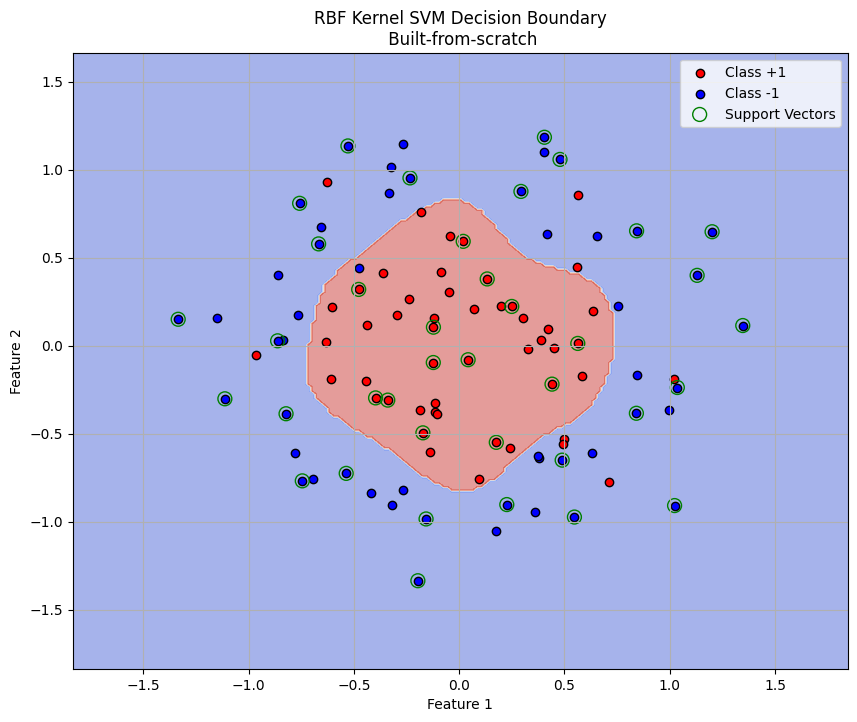

In [61]:
# Plot the decision boundary and the data points
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.5)
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='red', label='Class +1', edgecolors='k')
plt.scatter(X[y == -1, 0], X[y == -1, 1], color='blue', label='Class -1', edgecolors='k')
plt.scatter(X[sv_indices, 0], X[sv_indices, 1], s=100, facecolors='none', edgecolors='green', label='Support Vectors') # Highlight SVs
plt.title('RBF Kernel SVM Decision Boundary\n Built-from-scratch')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

### Solving the SVM Optimization Problem (Using Scikit-learn)

Implementing the full SVM optimization algorithm is instructional. For practical applications, specialized libraries like `scikit-learn` provide highly optimized implementations. We can use `sklearn.svm.SVC` and specify the `kernel='rbf'` to leverage the kernel trick without needing to implement the solver ourselves. Scikit-learn uses an efficient C++ based solver (LIBSVM).

In [62]:
from sklearn.svm import SVC

In [63]:
# Initialize SVC with an RBF kernel
# We use a similar gamma value as our custom kernel for comparison
svc_model = SVC(kernel='rbf', gamma=gamma_val, C=1.0) # C is the regularization parameter

# Train the SVM model
svc_model.fit(X, y)

# Make predictions
y_pred_sk = svc_model.predict(X)

# Calculate accuracy
print(f"Model Accuracy on training data: {accuracy(y, y_pred_sk)*100:.1f}%")

Model Accuracy on training data: 91.0%


### Visualize the Decision Boundary

Let's visualize the decision boundary created by the RBF Kernel SVM. This will show how it successfully separates the non-linear circular data.

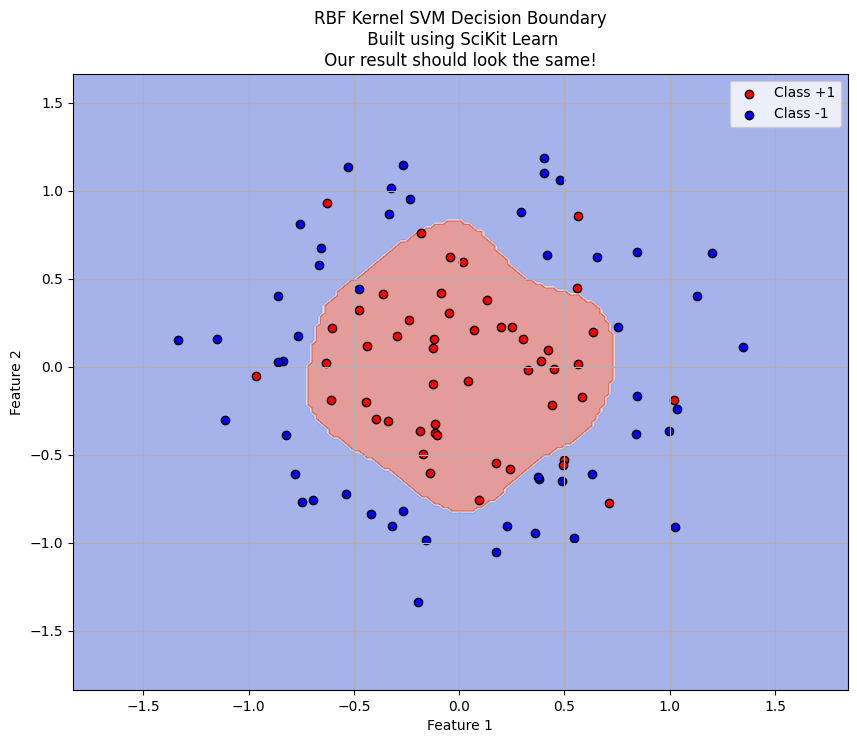

In [64]:
# Predict the class for each point in the mesh
Z_sk = svc_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z_sk = Z_sk.reshape(xx.shape)

# Plot the decision boundary and the data points
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z_sk, cmap=plt.cm.coolwarm, alpha=0.5)
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='red', label='Class +1', edgecolors='k')
plt.scatter(X[y == -1, 0], X[y == -1, 1], color='blue', label='Class -1', edgecolors='k')
plt.title('RBF Kernel SVM Decision Boundary\n Built using SciKit Learn\n Our result should look the same! ')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()